<a href="https://colab.research.google.com/github/bavinkdevadas-hub/ML-Projects/blob/main/Student%20Performance%20Prediction%20System/Student_Performance_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Problem statement

Educational institutions struggle to identify students who are at risk of poor academic performance early. This project predicts student performance using historical academic and behavioural data to support timely intervention.

Objective
To build a machine learning model that predicts whether a student will perform well or poorly based on multiple factors and provide insights for improvement.

Dataset
Student academic dataset containing
Attendance percentage
Internal assessment marks
Previous semester grades
Study hours
Participation in activities
Socio economic indicators
You can use a public dataset or create a realistic one.

Technologies used
Python
Pandas
NumPy
Matplotlib and Seaborn
Scikit learn
Jupyter Notebook.

Workflow
1 Data understanding and problem definition
2 Data cleaning and handling missing values
3 Exploratory data analysis
4 Feature selection and encoding
5 Train test split
6 Model building using Logistic Regression Random Forest
7 Model evaluation using accuracy precision recall and confusion matrix
8 Result interpretation and insights
9 Conclusion and future scope.

Output
Prediction of student performance category
Important features influencing performance
Visual dashboards showing trends

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/Student_Academic_Performance_100k.csv")
df

,Student_ID,Age,Gender,Attendance_Percentage,Internal_Assessment_Marks,Previous_Semester_Grade,Study_Hours_Per_Day,Activity_Participation,Family_Income_Level,Parent_Education,Internet_Access,Scholarship,Final_Grade,Performance_Category
0,STU000001,19,Female,76.9,60.9,65.5,13.7,Multiple,Lower-Middle,High School,Yes,No,78.5,Good
1,STU000002,24,Female,86.3,59.6,76.8,4.0,Cultural,Middle,High School,Yes,No,67.9,Average
2,STU000003,21,Male,77.6,57.6,67.8,4.3,Multiple,Low,High School,Yes,No,53.4,Pass
3,STU000004,21,Female,65.3,36.0,47.4,4.5,NaN,Middle,Diploma,No,No,60.5,Average
4,STU000005,18,Male,70.6,30.4,48.5,5.9,Clubs,Lower-Middle,Master's,Yes,No,64.1,Average
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,STU099996,22,Female,70.7,55.4,58.5,5.9,NaN,Low,Bachelor's,Yes,No,59.6,Average
99996,STU099997,22,Female,96.2,24.7,51.4,1.3,NaN,Middle,Diploma,No,No,44.7,Pass
99997,STU099998,21,Male,72.9,27.7,58.1,1.0,Multiple,Middle,Bachelor's,Yes,No,48.3,Pass
99998,STU099999,20,Female,67.6,53.0,57.6,6.0,Clubs,Low,Master's,Yes,No,56.2,Average


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Student_ID                 100000 non-null  object 
 1   Age                        100000 non-null  int64  
 2   Gender                     100000 non-null  object 
 3   Attendance_Percentage      100000 non-null  float64
 4   Internal_Assessment_Marks  100000 non-null  float64
 5   Previous_Semester_Grade    100000 non-null  float64
 6   Study_Hours_Per_Day        100000 non-null  float64
 7   Activity_Participation     65956 non-null   object 
 8   Family_Income_Level        100000 non-null  object 
 9   Parent_Education           100000 non-null  object 
 10  Internet_Access            100000 non-null  object 
 11  Scholarship                100000 non-null  object 
 12  Final_Grade                100000 non-null  float64
 13  Performance_Category       100

In [ ]:
df.drop(['Student_ID'],axis=1,inplace=True)

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Attendance_Percentage,0
Internal_Assessment_Marks,0
Previous_Semester_Grade,0
Study_Hours_Per_Day,0
Activity_Participation,34044
Family_Income_Level,0
Parent_Education,0
Internet_Access,0


In [ ]:
df['Activity_Participation'].fillna(df["Activity_Participation"].mode()[0],inplace=True)

/tmp/ipykernel_5402/3188850957.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Activity_Participation'].fillna(df["Activity_Participation"].mode()[0],inplace=True)


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Attendance_Percentage,0
Internal_Assessment_Marks,0
Previous_Semester_Grade,0
Study_Hours_Per_Day,0
Activity_Participation,0
Family_Income_Level,0
Parent_Education,0
Internet_Access,0


In [ ]:
df.duplicated().sum()

np.int64(0)

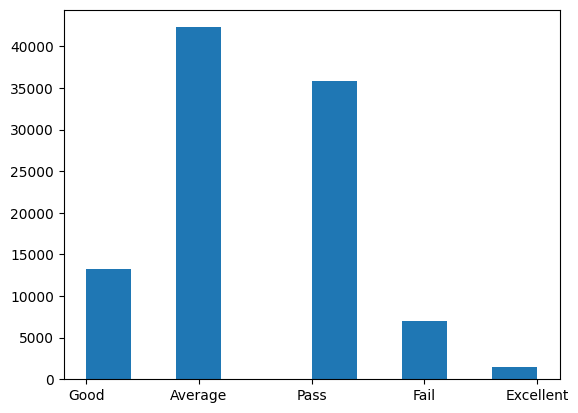

In [ ]:
plt.hist(df['Performance_Category'])
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Age                        100000 non-null  int64  
 1   Gender                     100000 non-null  object 
 2   Attendance_Percentage      100000 non-null  float64
 3   Internal_Assessment_Marks  100000 non-null  float64
 4   Previous_Semester_Grade    100000 non-null  float64
 5   Study_Hours_Per_Day        100000 non-null  float64
 6   Activity_Participation     100000 non-null  object 
 7   Family_Income_Level        100000 non-null  object 
 8   Parent_Education           100000 non-null  object 
 9   Internet_Access            100000 non-null  object 
 10  Scholarship                100000 non-null  object 
 11  Final_Grade                100000 non-null  float64
 12  Performance_Category       100000 non-null  object 
dtypes: float64(5), int64(1), objec

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Activity_Participation'] = le.fit_transform(df['Activity_Participation'])
df['Internet_Access'] = le.fit_transform(df['Internet_Access'])
df['Scholarship'] = le.fit_transform(df['Scholarship'])

In [ ]:
df['Family_Income_Level'] = df['Family_Income_Level'].replace({
    'Low': 0,
    'Lower-Middle': 1,
    'Middle': 2,
    'Upper-Middle': 3,
    'High': 4
})

df['Parent_Education'] = df['Parent_Education'].replace({
    'High School': 0,
    'Diploma': 1,
    "Bachelor's": 2,
    "Master's": 3,
    'Doctorate': 4
})

/tmp/ipykernel_5402/853061768.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Family_Income_Level'] = df['Family_Income_Level'].replace({
/tmp/ipykernel_5402/853061768.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Parent_Education'] = df['Parent_Education'].replace({


In [ ]:
df['Performance_Category'] = df['Performance_Category'].replace({
    'Fail': 0,
    'Pass': 1,
    'Average': 2,
    'Good': 3,
    'Excellent': 4
})

/tmp/ipykernel_5402/4209994763.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Performance_Category'] = df['Performance_Category'].replace({


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Age                        100000 non-null  int64  
 1   Gender                     100000 non-null  int64  
 2   Attendance_Percentage      100000 non-null  float64
 3   Internal_Assessment_Marks  100000 non-null  float64
 4   Previous_Semester_Grade    100000 non-null  float64
 5   Study_Hours_Per_Day        100000 non-null  float64
 6   Activity_Participation     100000 non-null  int64  
 7   Family_Income_Level        100000 non-null  int64  
 8   Parent_Education           100000 non-null  int64  
 9   Internet_Access            100000 non-null  int64  
 10  Scholarship                100000 non-null  int64  
 11  Final_Grade                100000 non-null  float64
 12  Performance_Category       100000 non-null  int64  
dtypes: float64(5), int64(8)
memory

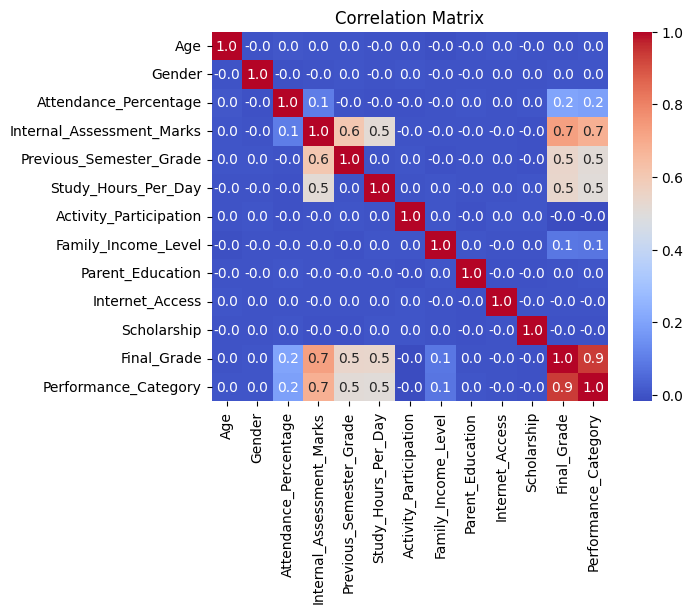

In [ ]:
# Correlation matrix
corr_matrix=df.corr()
# Heatmap of correlation matrix
sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')# 0.01f should be given for float values, d for integers
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df.drop(['Final_Grade'],axis=1,inplace=True)

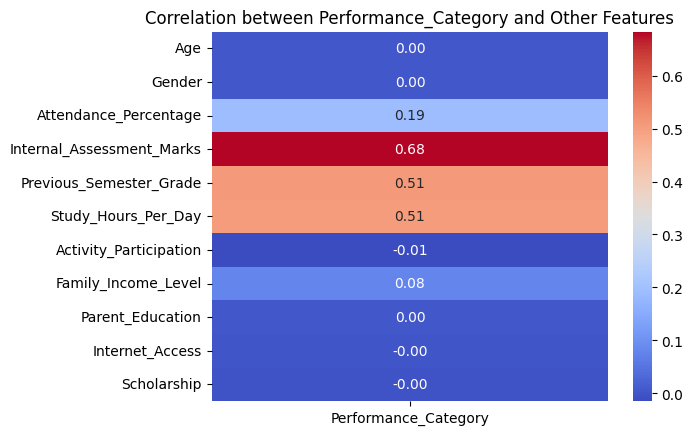

In [ ]:
# Calculate the correlation between 'Performance_Category' and all other columns
Performance_Category_corr=df.corr()['Performance_Category']

# Remove the correlation of 'Performance_Category'with itself (which is always 1)
Performance_Category_corr=Performance_Category_corr.drop('Performance_Category')
# Create a heatmap to visualize the correlations
sns.heatmap(Performance_Category_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',
            cbar=True,annot_kws={'size':10}) # to_frame() converts Series to DataFrame for heatmap
plt.title('Correlation between Performance_Category and Other Features')
plt.show()

In [ ]:
df.drop(['Age','Gender','Activity_Participation','Parent_Education','Internet_Access','Scholarship'],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Attendance_Percentage      100000 non-null  float64
 1   Internal_Assessment_Marks  100000 non-null  float64
 2   Previous_Semester_Grade    100000 non-null  float64
 3   Study_Hours_Per_Day        100000 non-null  float64
 4   Family_Income_Level        100000 non-null  int64  
 5   Performance_Category       100000 non-null  int64  
dtypes: float64(4), int64(2)
memory usage: 4.6 MB


<Axes: >

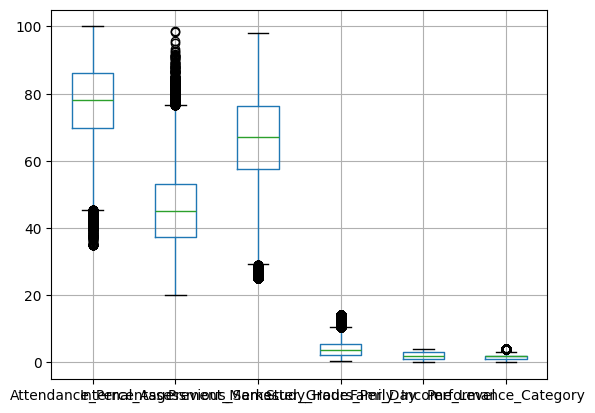

In [ ]:
df.boxplot()

In [ ]:
# Function to remove outliers using the IQR method except for one column
def remove_outliers_iqr(df,exclude_column):


  for col in df.columns:

   # Skip the specified column
    if col==exclude_column:
      continue
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    # Filter the DataFrame to remove rows with outliers in each column
    df=df[(df[col]>=lower_bound)&(df[col]<=upper_bound)]
  return df


# Specify the column to exclude
df_cleaned=remove_outliers_iqr(df,exclude_column='Performance_Category')
df=df_cleaned

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
 #Select the features that you want to scale
features = ['Attendance_Percentage', 'Internal_Assessment_Marks', 'Previous_Semester_Grade','Study_Hours_Per_Day','Family_Income_Level']
# Create a MinMaxScaler object
scaler = MinMaxScaler()
# Fit the scaler to your data and transform it
scaled_data = scaler.fit_transform(df[features])
# Create a DataFrame from scaled_data with the correct column names
scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=scaled_df
y=df['Performance_Category']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
# Train a baseline logistic regression model
model=LogisticRegression()
model.fit(x_train,y_train)
# Predict and evaluate the model
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"baseline model accuracy:{accuracy:.2f}")

baseline model accuracy:0.63


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.49673664518811056


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.6041155684888797


In [ ]:
from xgboost import XGBClassifier
model=XGBClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.6215339846185824


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
model=AdaBoostClassifier()
model.fit(x_train,y_train)
pred=model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.5849511536063189


In [ ]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()
#track best fold data
best_accuracy=0
best_fold=-1

# Save best fold's data
best_x_train = None
best_y_train = None
best_x_test = None
best_y_test = None
best_y_pred = None

# Loop over each fold
for fold, (train_index, test_index) in enumerate(kf.split(x), 1):
    x_train, x_test = x.iloc[train_index], x.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    model.fit(x_train, y_train)

    # Predict
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    # Update best fold
    if acc > best_accuracy:
      best_accuracy = acc
      best_fold = fold
      best_x_train = x_train
      best_y_train = y_train
      best_x_test = x_test
      best_y_test = y_test
      best_y_pred = y_pred
 # Output best fold details
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1 Accuracy: 0.6294949075036375


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2 Accuracy: 0.6321450841820827


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 3 Accuracy: 0.6319891914362918


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 4 Accuracy: 0.6345874038661401
Fold 5 Accuracy: 0.6263250883392226

 Best Fold: 4 with Accuracy: 0.6345874038661401


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model = LogisticRegression()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.6345874038661401

In [ ]:
model=DecisionTreeClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.5028580336728331

In [ ]:
model=RandomForestClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.6114633132404905

In [ ]:
model=XGBClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.6256495531074621

In [ ]:
model=AdaBoostClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

0.5716586988152151

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Defining the ANN model
model = Sequential()
model.add(Dense(64, input_shape=(5,),activation='relu'))  # Hidden Layer 1
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))              # Hidden Layer 2
model.add(Dense(5, activation='softmax'))             # Output Layer

# Compiling the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 3. Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Training the model
model.fit(best_x_train, best_y_train, epochs=25, batch_size=32)

Epoch 1/25
2406/2406 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6272 - loss: 0.8230
Epoch 2/25
2406/2406 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6278 - loss: 0.8223
Epoch 3/25
2406/2406 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6278 - loss: 0.8225
Epoch 4/25
2406/2406 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6277 - loss: 0.8223
Epoch 5/25
2406/2406 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6279 - loss: 0.8223
Epoch 6/25
2406/2406 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6283 - loss: 0.8220
Epoch 7/25
2406/2406 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6290 - loss: 0.8220
Epoch 8/25
2406/2406 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6278 - loss: 0.8218
Epoch 9/25
2406/2406 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6290 - loss: 0.8220
Epoch 10/25
2406/2406 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6284 - loss: 0.8219
Epoch 11/25
2406/2406 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6277 - loss: 0.8215
Epoch 12/25
2406/2406 ━━━━━━━━

In [ ]:
# Evaluating the model
loss, accuracy = model.evaluate( best_x_test, best_y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

602/602 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6315 - loss: 0.8144
Model Accuracy: 63.15%


##Conclusion
This project successfully developed a Student Performance Prediction System using both machine learning and deep learning techniques. The dataset was preprocessed through data cleaning, encoding of categorical variables, and feature scaling to improve model performance. Several machine learning algorithms and a deep learning model were trained and evaluated. Among all the models, the **best machine learning model achieved an accuracy of 63.46%**, while the **deep learning model achieved an accuracy of 63.15%**. These results indicate that the machine learning model performed slightly better for predicting student performance on the given dataset.

In conclusion, the proposed system demonstrates how data-driven models can be used to predict student performance and support educational institutions in identifying students who may require additional academic assistance. Although the achieved accuracy shows that the model can provide useful predictions, there is scope for improvement by using larger datasets, including additional student-related features, and optimizing the model parameters. Overall, this project highlights the practical application of machine learning in the field of educational analytics.
